In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

# Para instalar imbalanced-learn si no lo tienes: %pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# Ignorar warnings
import warnings
warnings.filterwarnings('ignore')

## 1 Análisis Exploratorio de Datos (AED)

In [109]:
# Carga de datos
data = pd.read_csv('RTA Dataset.csv')
data.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [110]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [111]:
# Estadísticas descriptivas de variables numéricas
data.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [112]:
# Verificar valores nulos
nulos = data.isnull().sum().sum()
print(f"Valores nulos en el dataset: {nulos}")

Valores nulos en el dataset: 20057


In [113]:
print("Valores faltantes por columna:")
print(data.isnull().sum())

Valores faltantes por columna:
Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                

Las dos que son numericas int ( number_of_vehicles_involved  
number_of_casualties ) no tienen datos faltantes. POr ende no se hara imputacion por media, ni mediana a esas.
Sin embargo hay varias categoricas que si tienen datos faltantes

In [114]:
#imputacion mediante la moda para las variables categoricas
df_pandas_cat = data.select_dtypes(include=['object'])
df_pandas_cat.head()

mode_values = df_pandas_cat.mode().iloc[0]
data[df_pandas_cat.columns] = data[df_pandas_cat.columns].fillna(mode_values)

print("Valores faltantes después de imputar (moda):")
print(data.isnull().sum())

Valores faltantes después de imputar (moda):
Time                           0
Day_of_week                    0
Age_band_of_driver             0
Sex_of_driver                  0
Educational_level              0
Vehicle_driver_relation        0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Service_year_of_vehicle        0
Defect_of_vehicle              0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Casualty_class                 0
Sex_of_casualty                0
Age_band_of_casualty           0
Casualty_severity              0
Work_of_casuality              0
Fitness_of_casuality           

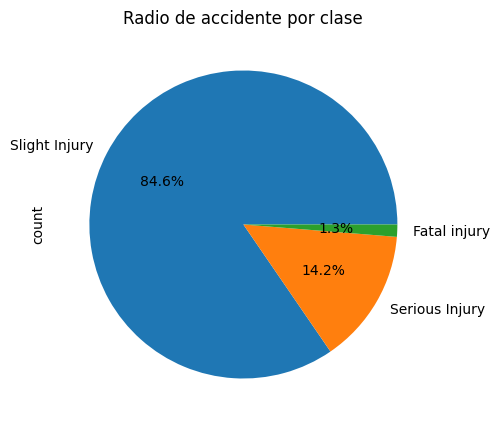

In [116]:
#radio de accidente por clase
plt.figure(figsize=(8,5))
data["Accident_severity"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Radio de accidente por clase")
plt.show()

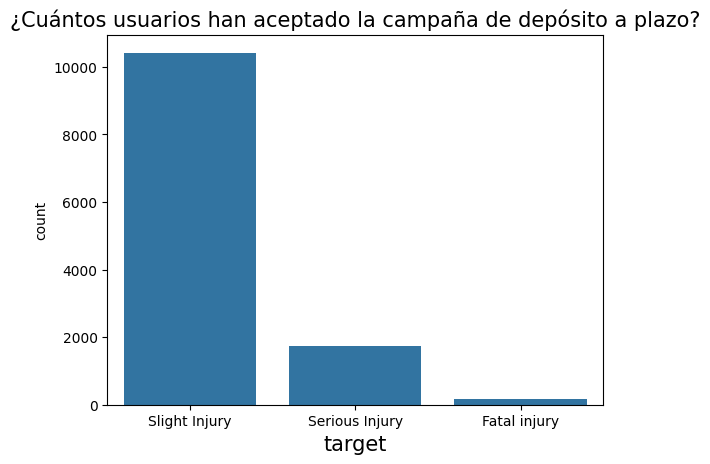

In [138]:
sns.countplot(data = data, x = 'Accident_severity')
plt.xlabel('target', fontsize = 15)
plt.title('¿Cuántos usuarios han aceptado la campaña de depósito a plazo?', fontsize = 15)
plt.show()

Hay un claro desvalance, tan solo hay un 1.3% de casos para "fatal_injury". Hara que el modelo prediga principalmente "Slight Injury" pues tendra mayor predominancia de datos para poder encontrar patrones que le hagan predecir esa variable. Puede ser que el modelo logre buen accuracy pero no seria util en el mundo real.

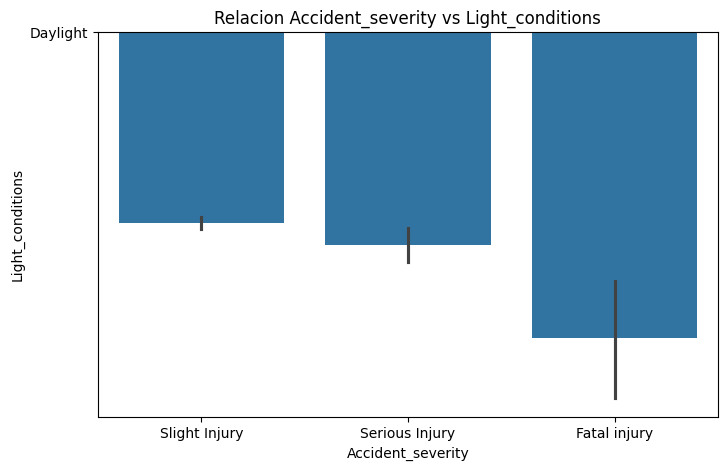

In [117]:
#relacion variable predictora "Light_conditions", "Weather_conditions", "Cause_of_accident", "Driving_experience" con la severidad del accident mediante grafico de barras
plt.figure(figsize=(8,5))
sns.barplot(x=data["Accident_severity"], y=data["Light_conditions"])
plt.title("Relacion Accident_severity vs Light_conditions")
plt.show()

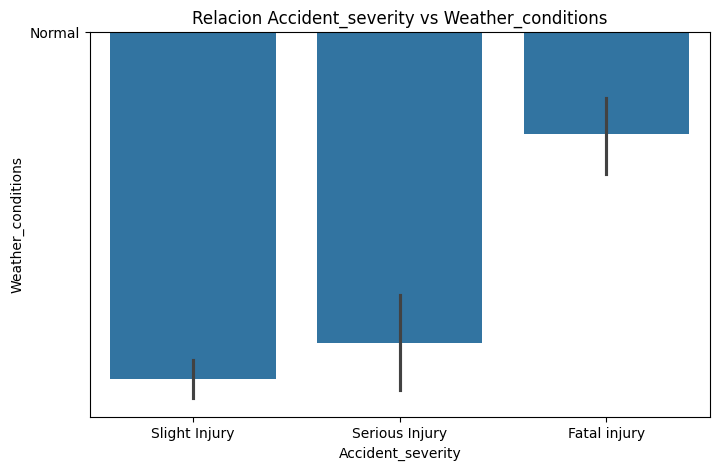

In [118]:
plt.figure(figsize=(8,5))
sns.barplot(x=data["Accident_severity"], y=data["Weather_conditions"])
plt.title("Relacion Accident_severity vs Weather_conditions")
plt.show()

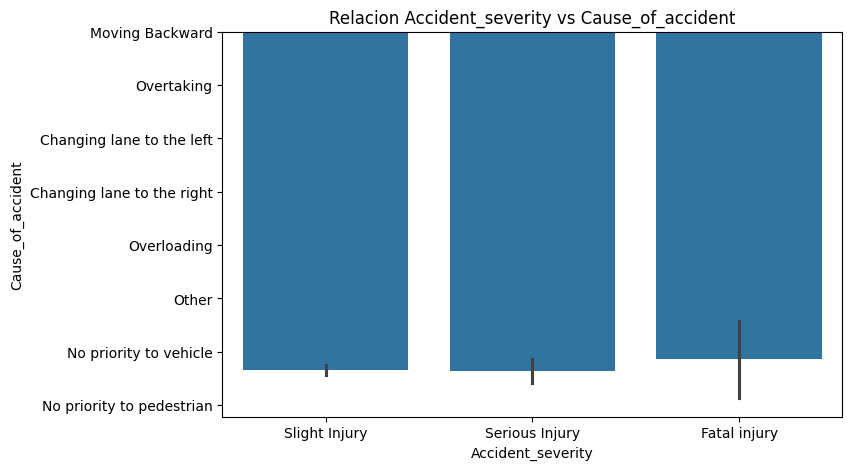

In [119]:
plt.figure(figsize=(8,5))
sns.barplot(x=data["Accident_severity"], y=data["Cause_of_accident"])
plt.title("Relacion Accident_severity vs Cause_of_accident")
plt.show()

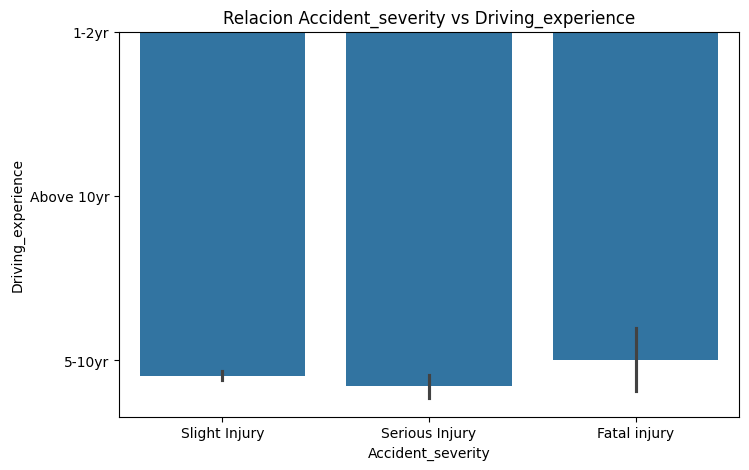

In [120]:
plt.figure(figsize=(8,5))
sns.barplot(x=data["Accident_severity"], y=data["Driving_experience"])
plt.title("Relacion Accident_severity vs Driving_experience")
plt.show()


Interpretacion: Se ve una relacion entre que el clima es normal y la severidad del accidente. Tiene sentido pues si esta lloviendo, hay neblina se espera que el accidente occurra con mayor severidad. Y por caso contrario si el clima esta despejado se espera que el accidente haya sido menor. Tambien se ve una clara relacion entre la cantidad de luz y y la severidad del accidente. Tambien tiene sentido que a menor cantidad de luz el accidente ocurra con mucha mayor catastroficidad

In [121]:
#nueva feature temporal franja horaria mañana, tarde, noche
data["Time"] = pd.to_datetime(data["Time"])
data["Franja_horaria"] = data["Time"].dt.hour
data["Franja_horaria"] = pd.cut(data["Franja_horaria"], bins=[0, 6, 12, 18, 24], labels=["Noche", "Mañana", "Tarde", "Noche"], ordered=False)
data.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Franja_horaria
0,2026-05-18 17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,na,na,na,na,Driver,Normal,Not a Pedestrian,Moving Backward,Slight Injury,Tarde
1,2026-05-18 17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,na,na,na,na,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury,Tarde
2,2026-05-18 17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,Unknown,...,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the left,Serious Injury,Tarde
3,2026-05-18 01:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Unknown,...,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury,Noche
4,2026-05-18 01:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Owner,5-10yrs,...,na,na,na,na,Driver,Normal,Not a Pedestrian,Overtaking,Slight Injury,Noche


se podria usar para predecir en que franja horaria occurren los accidentes mas graves o tal vez los mas leves


## 2 Preprocesamiento de Datos


In [122]:
#seleccionar caracterisitcas relevantes para el modelado, descartando variables con alta cardinalidad o baja varianza


In [123]:
# --- PREPROCESAMIENTO: LABEL ENCODING ---
data['c_driving_experience'] = LabelEncoder().fit_transform(data.Driving_experience.values)
data['c_age_band'] = LabelEncoder().fit_transform(data.Age_band_of_casualty.values)
data['c_casualty_sex'] = LabelEncoder().fit_transform(data.Sex_of_casualty.values)
data['c_accident_severity'] = LabelEncoder().fit_transform(data.Accident_severity.values)
data.drop(['Driving_experience', 'Age_band_of_casualty', 'Sex_of_casualty', 'Accident_severity'], axis=1)




,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Franja_horaria,c_driving_experience,c_age_band,c_casualty_sex,c_accident_severity
0,2026-05-18 17:02:00,Monday,18-30,Male,Above high school,Employee,Automobile,Owner,Above 10yr,No defect,...,na,Driver,Normal,Not a Pedestrian,Moving Backward,Tarde,0,5,2,2
1,2026-05-18 17:02:00,Monday,31-50,Male,Junior high school,Employee,Public (> 45 seats),Owner,5-10yrs,No defect,...,na,Driver,Normal,Not a Pedestrian,Overtaking,Tarde,3,5,2,2
2,2026-05-18 17:02:00,Monday,18-30,Male,Junior high school,Employee,Lorry (41?100Q),Owner,Unknown,No defect,...,3,Driver,Normal,Not a Pedestrian,Changing lane to the left,Tarde,0,1,1,1
3,2026-05-18 01:06:00,Sunday,18-30,Male,Junior high school,Employee,Public (> 45 seats),Governmental,Unknown,No defect,...,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Noche,2,0,0,2
4,2026-05-18 01:06:00,Sunday,18-30,Male,Junior high school,Employee,Automobile,Owner,5-10yrs,No defect,...,na,Driver,Normal,Not a Pedestrian,Overtaking,Noche,1,5,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,2026-05-18 16:15:00,Wednesday,31-50,Male,Junior high school,Employee,Lorry (11?40Q),Owner,Unknown,No defect,...,na,Driver,Normal,Not a Pedestrian,No distancing,Tarde,1,5,2,2
12312,2026-05-18 18:00:00,Sunday,Unknown,Male,Elementary school,Employee,Automobile,Owner,Unknown,No defect,...,na,Driver,Normal,Not a Pedestrian,No distancing,Tarde,2,5,2,2
12313,2026-05-18 13:55:00,Sunday,Over 51,Male,Junior high school,Employee,Bajaj,Owner,2-5yrs,No defect,...,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Tarde,2,1,1,1
12314,2026-05-18 13:55:00,Sunday,18-30,Female,Junior high school,Employee,Lorry (41?100Q),Owner,2-5yrs,No defect,...,na,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Tarde,3,5,2,2


como los modelos no entienden texto, poner variables como driving experience que divide sus datos entre mayor a x cantidad de edad y menor de x cantidad de edad, se convierte a numeros que correponde a cada categoria del dato. Lo mismo seria con accident severity, en vez de ser slight_injury, Serious_injury, seria 1,2,3.

In [124]:
#escalado
scaler = StandardScaler()

# versione escaladas variables numericas
data['Number_of_vehicles_involved_scaled'] = scaler.fit_transform(data[['Number_of_vehicles_involved']])
data['Number_of_casualties_scaled'] = scaler.fit_transform(data[['Number_of_casualties']])

columns_to_drop_before_ohe = [
    'Driving_experience',
    'Age_band_of_casualty',
    'Sex_of_casualty',
    'Accident_severity',
    'Time',
    'Number_of_casualties',
    'Number_of_vehicles_involved'
]

X_preprocessed = data.drop(columns=columns_to_drop_before_ohe, errors='ignore')

categorical_cols = X_preprocessed.select_dtypes(include=['object', 'category']).columns

#one hot encoding
X = pd.get_dummies(X_preprocessed, columns=categorical_cols, drop_first=True)


y = data['c_accident_severity']

if 'c_accident_severity' in X.columns:
    X = X.drop('c_accident_severity', axis=1)


como solo habia dos variables numericas, solo esas dos se pueden trabajar con el scaler

escalar es necesario para modelos que predicen en base a las distancia de los datos, modelos como MLP que usa desenso gradiente o KNN que se basa en distancias geometricas,
si una variable es grande aplastaria a las pequeñas, lo que causaria inestabilidad numerica

In [125]:
#divicion del dtasaet 70-15-15 test, validation, train con ostratificacion por calse
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)


Justificación SMOTE: Elegimos SMOTE (sobremuestreo sintético) porque hacer submuestreo eliminaría masivamente registros legítimos, haciendo perder información valiosa de los perfiles normales.

In [126]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Distribución tras SMOTE en Train:", y_train_sm.value_counts().to_dict())

Distribución tras SMOTE en Train: {2: 7290, 0: 7290, 1: 7290}


## 3 Modelado

### 1. K-Nearest Neighbors (KNN)
**Paradigma:** Aprendizaje Basado en Instancias.
**Hiperparámetros:** `n_neighbors=5`. El algoritmo compara directamente datos nuevos con puntos existentes en memoria.

In [127]:
knn = KNeighborsClassifier(n_jobs=-1)
knn.fit(X_train_sm, y_train_sm)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]

### 2. Random Forest
**Paradigma:** Ensamble de Árboles (Divide y Vencerás).
**Hiperparámetros:** `n_estimators=50`, `max_depth=10`. Reducimos profundidad para evitar overfitting en un dataset tan artificialmente crecido.

In [128]:
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

### 3. Perceptrón Multicapa (MLP)
**Paradigma:** Aprendizaje Conexionista.
**Hiperparámetros:** `hidden_layer_sizes=(30, 10)`, `activation='relu'`. Al ser PCA, los datos ya son densos, por lo que una red pequeña suele bastar.

In [129]:
mlp = MLPClassifier(hidden_layer_sizes=(30, 10), activation='relu', max_iter=50, random_state=42)
mlp.fit(X_train_sm, y_train_sm)

y_pred_mlp = mlp.predict(X_test)
y_prob_mlp = mlp.predict_proba(X_test)[:, 1]

## 4 Evaluación de Modelos

In [130]:
print("=== CLASSIFICATION REPORT: KNN ===")
print(classification_report(y_test, y_pred_knn))

print("\n=== CLASSIFICATION REPORT: RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))

print("\n=== CLASSIFICATION REPORT: MLP ===")
print(classification_report(y_test, y_pred_mlp))

=== CLASSIFICATION REPORT: KNN ===
              precision    recall  f1-score   support

           0       0.08      0.04      0.06        23
           1       0.23      0.12      0.16       262
           2       0.85      0.93      0.89      1563

    accuracy                           0.80      1848
   macro avg       0.39      0.36      0.37      1848
weighted avg       0.75      0.80      0.77      1848


=== CLASSIFICATION REPORT: RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.33      0.13      0.19        23
           1       0.27      0.15      0.19       262
           2       0.86      0.93      0.90      1563

    accuracy                           0.81      1848
   macro avg       0.49      0.40      0.42      1848
weighted avg       0.77      0.81      0.79      1848


=== CLASSIFICATION REPORT: MLP ===
              precision    recall  f1-score   support

           0       0.11      0.09      0.10        23
           1

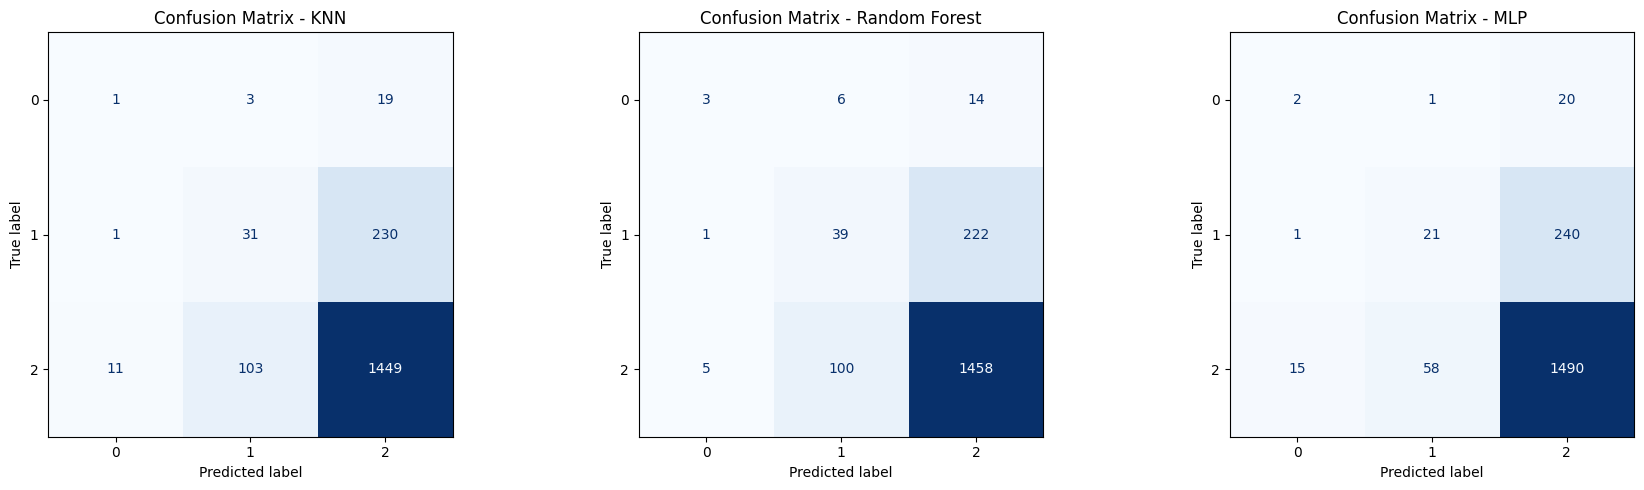

In [131]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix - KNN')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix - Random Forest')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp, ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('Confusion Matrix - MLP')

plt.tight_layout()
plt.show()

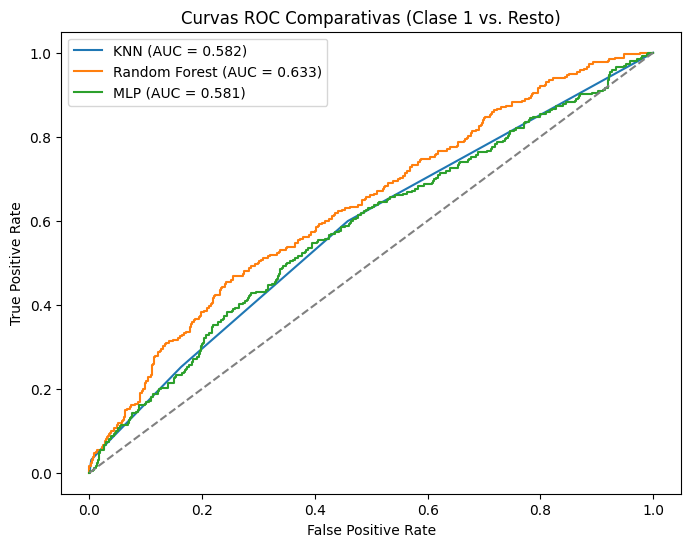

In [133]:
fpr_knn, tpr_knn, _ = roc_curve(y_test == 1, y_prob_knn)
fpr_rf, tpr_rf, _ = roc_curve(y_test == 1, y_prob_rf)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test == 1, y_prob_mlp)

plt.figure(figsize=(8,6))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc(fpr_knn, tpr_knn):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.3f})')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {auc(fpr_mlp, tpr_mlp):.3f})')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.title('Curvas ROC Comparativas (Clase 1 vs. Resto)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

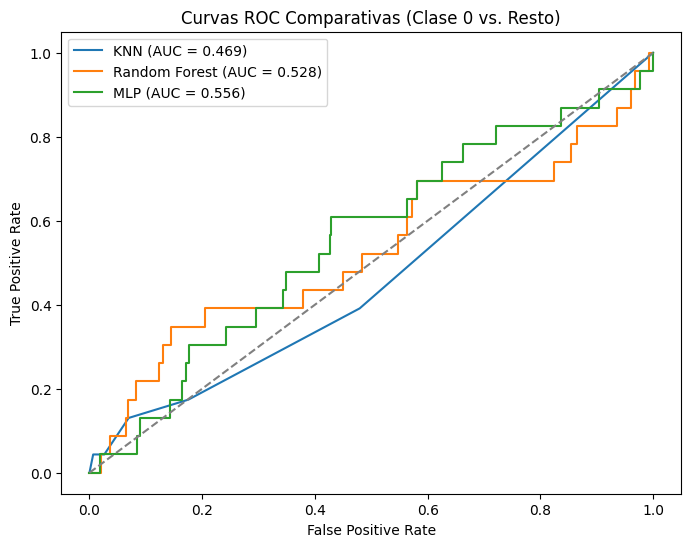

In [134]:
fpr_knn, tpr_knn, _ = roc_curve(y_test == 0, y_prob_knn)
fpr_rf, tpr_rf, _ = roc_curve(y_test == 0, y_prob_rf)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test == 0, y_prob_mlp)

plt.figure(figsize=(8,6))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc(fpr_knn, tpr_knn):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.3f})')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {auc(fpr_mlp, tpr_mlp):.3f})')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.title('Curvas ROC Comparativas (Clase 0 vs. Resto)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

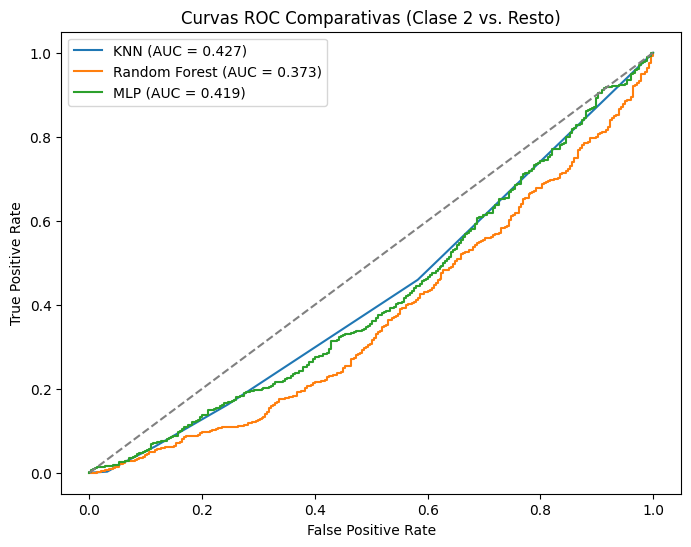

In [135]:
fpr_knn, tpr_knn, _ = roc_curve(y_test == 2, y_prob_knn)
fpr_rf, tpr_rf, _ = roc_curve(y_test == 2, y_prob_rf)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test == 2, y_prob_mlp)

plt.figure(figsize=(8,6))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc(fpr_knn, tpr_knn):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.3f})')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {auc(fpr_mlp, tpr_mlp):.3f})')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.title('Curvas ROC Comparativas (Clase 2 vs. Resto)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import average_precision_score

prec_knn, rec_knn, _ = precision_recall_curve(y_test, y_prob_knn)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
prec_mlp, rec_mlp, _ = precision_recall_curve(y_test, y_prob_mlp)

plt.figure(figsize=(8,6))
plt.plot(rec_knn, prec_knn, label=f'KNN (PR-AUC = {average_precision_score(y_test, y_prob_knn):.3f})')
plt.plot(rec_rf, prec_rf, label=f'Random Forest (PR-AUC = {average_precision_score(y_test, y_prob_rf):.3f})')
plt.plot(rec_mlp, prec_mlp, label=f'MLP (PR-AUC = {average_precision_score(y_test, y_prob_mlp):.3f})')
plt.title('Curvas Precision-Recall Comparativas')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

## 5 Análisis y Conclusiones

Comparacion de los modelos:
El modelo que mejor precision tuvo fue MLP
Sin embargo el modelo con mejor f1 score fue random forest.
Se esperaba que los modelos tengan muy poca precision a la hora de predcir si el accidente era grave, o medianamente grave pues como se vio al inicio los datos estaban totalmente desproporcionados. Se tendria que balancear las clases para hayar una mejor precision para las clase 0,1 del modelo

La consecuencia de una falso negativo decir que un conductor que cometio un accidente termino en accidente fatal cuando en realidad fue menor. Puede conllevar a consecuencias legales injustas
Por el otro caso el hacer que un conductor que causo un accidente muy grave pero el modelo predijo que era menor reciba una pena que deberia haber sido mayor, si el accidente en realidad si fue grave